# Level 1, Task 1

# Top Cuisines

## Objective
Identify the top 3 most common cuisines and calculate the percentage of restaurants serving each cuisine.

## Analysis

#  Upload the Dataset

In [ ]:
# from google.colab import files

# uploaded = files.upload()
# print(uploaded.keys())

Saving Dataset .csv(cognifyz).csv to Dataset .csv(cognifyz).csv
dict_keys(['Dataset .csv(cognifyz).csv'])


# Load the Dataset

In [1]:
import pandas as pd

file_path = '/Dataset .csv(cognifyz).csv'

df = pd.read_csv(file_path, encoding='latin1')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9551, 21)


# Display the Dataset Columns

In [2]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


# Determine the Top 3 Most Common Cuisines

In [3]:
cuisine_data = df['Cuisines'].dropna().str.split(',').explode().str.strip()

top_3 = cuisine_data.value_counts().head(3)

print("Top 3 Most Common Cuisines:")
print(top_3)

Top 3 Most Common Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


# Calculate the Percentage of Restaurants Serving Each Top Cuisine

In [ ]:
top_cuisines = pd.DataFrame({
    'Cuisine': top_3.index,
    'Restaurant Count': top_3.values
})

top_cuisines['Percentage of Restaurants'] = (
    top_cuisines['Restaurant Count'] / len(df) * 100
).round(2)

top_cuisines

,Cuisine,Restaurant Count,Percentage of Restaurants
0,North Indian,3960,41.46
1,Chinese,2735,28.64
2,Fast Food,1986,20.79


# Visualize the Top 3 Cuisines

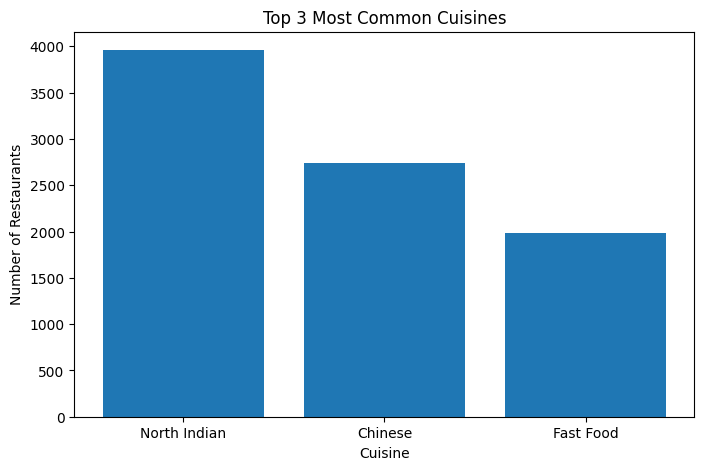

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    top_cuisines['Cuisine'],
    top_cuisines['Restaurant Count']
)

plt.title('Top 3 Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')

plt.show()

### Key Findings

- North Indian is the most commonly served cuisine among the restaurants in the dataset.
- Chinese is the second most common cuisine.
- Fast Food ranks third among the top three most common cuisines.
- North Indian cuisine has the highest number of restaurants serving it.

# Level 1, Task 2

# Identify the City with the Highest Number of Restaurants

In [ ]:
city_counts = df['City'].value_counts()

city_counts.head(10)

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Lucknow,21
Ahmedabad,21
Amritsar,21


# Calculate Average Rating by City

In [ ]:
city_avg_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

city_avg_rating.head(10)

,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000
Beechworth,4.600000
London,4.535000
Taguig City,4.525000
Secunderabad,4.500000


# Identify the City with the Highest Average Rating

In [ ]:
highest_rated_city = city_avg_rating.idxmax()
highest_average_rating = city_avg_rating.max()

print("City with Highest Average Rating:", highest_rated_city)
print("Highest Average Rating:", round(highest_average_rating, 2))

City with Highest Average Rating: Inner City
Highest Average Rating: 4.9


# Level 1 – Task 3

# Price Range Distribution

# Count Restaurants by Price Range

In [ ]:
price_range_counts = df['Price range'].value_counts().sort_index()

print("Number of Restaurants in Each Price Range:")
print(price_range_counts)

Number of Restaurants in Each Price Range:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


# Calculate Percentage of Restaurants in Each Price Range

In [ ]:
price_range_percentage = (
    price_range_counts / len(df) * 100
).round(2)

print("Percentage of Restaurants in Each Price Range:")
print(price_range_percentage)

Percentage of Restaurants in Each Price Range:
Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64


# Visualize Price Range Distribution

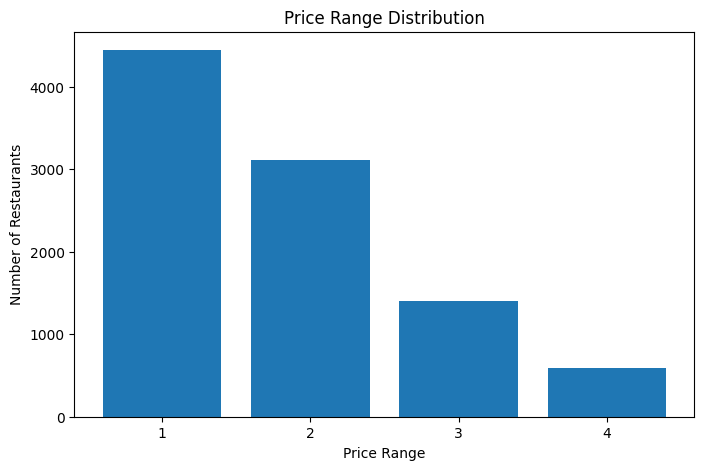

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    price_range_counts.index.astype(str),
    price_range_counts.values
)

plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')

plt.show()

# Level 1 – Task 4


# Online Delivery
* Calculate Percentage of Restaurants Offering Online Delivery

In [ ]:
online_delivery_percentage = (
    df['Has Online delivery'].value_counts(normalize=True) * 100
).round(2)

print("Percentage of Restaurants Offering Online Delivery:")
print(online_delivery_percentage)

Percentage of Restaurants Offering Online Delivery:
Has Online delivery
No     74.34
Yes    25.66
Name: proportion, dtype: float64


* Compare Average Ratings With and Without Online Delivery

In [ ]:
average_rating_delivery = (
    df.groupby('Has Online delivery')['Aggregate rating']
    .mean()
    .round(2)
)

print("Average Rating by Online Delivery Availability:")
print(average_rating_delivery)

Average Rating by Online Delivery Availability:
Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64
